# SVM Classifier

In [1]:
# Load and split data
import pandas as pd
from sklearn.model_selection import train_test_split
from data_cleaner import preprocess_features

df_pos = pd.read_csv('../../data/inputs/clf_descriptors_positive_staphylococcus.csv')
df_neg = pd.read_csv('../../data/inputs/clf_descriptors_negative_02_dataset.csv')

#concat
df = pd.concat([df_pos, df_neg])

#split - "ACTIVITY" column is the target
X = df.drop(columns=['SEQUENCE','ACTIVITY'])
y = df['ACTIVITY']
X = preprocess_features(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# SVM
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# hyperparameter dictionary
param_grid = {'C': [0.1, 1, 10, 100, 1000], 'gamma': [1, 0.1, 0.01, 0.001, 0.0001], 'kernel': ['rbf']}

# GridSearchCV
from sklearn.model_selection import GridSearchCV
clf = GridSearchCV(SVC(), param_grid, refit=True, verbose=0)
clf.fit(X_train, y_train)

# best parameters
print(clf.best_params_)

{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}


Classification report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86        84
           1       0.89      0.85      0.87        93

    accuracy                           0.86       177
   macro avg       0.86      0.87      0.86       177
weighted avg       0.87      0.86      0.86       177

Precision: 0.8876404494382022
Recall: 0.8494623655913979
ROC AUC: 0.8652073732718895

Confusion Matrix:
[[74 10]
 [14 79]]


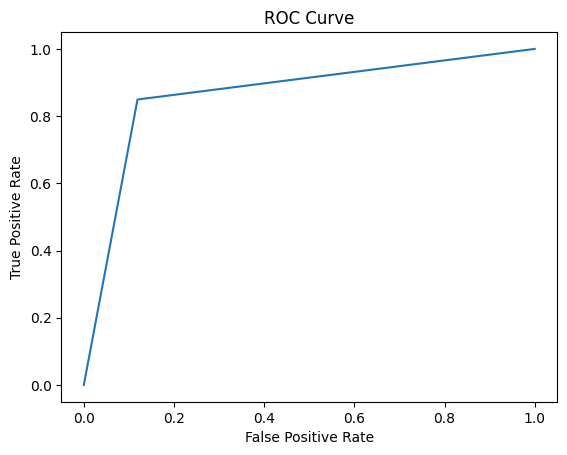

In [10]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score
model = clf.best_estimator_
y_pred = model.predict(X_test)
print(f'Classification report:\n{classification_report(y_test, y_pred)}')

# precision, recall, f1-score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'ROC AUC: {roc_auc}')

# confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# plot ROC curve
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()